In [3]:
# AlexNet Demonstration Notebook

# Install PyTorch
!pip install torch torchvision

# Import Libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import requests
from io import BytesIO
import timm

In [6]:
# Load Pretrained Model

# Here are a few options:

model = models.alexnet(pretrained=True)
# model = models.resnet50(pretrained=True)
# model = timm.create_model("convnext_base", pretrained=True)

model.eval()  # Set the model to evaluation mode

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

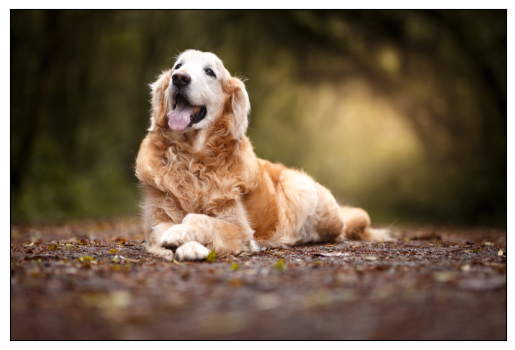

In [13]:
# Download a sample image to classify:

url = "https://pettownsendvet.com/wp-content/uploads/2023/01/iStock-1052880600-2048x1365.jpg"
# url ="https://img.freepik.com/free-vector/flat-mice-collection-with-different-poses_23-2147737868.jpg"
# or choose the image you would like to test

response = requests.get(url)
img = Image.open(BytesIO(response.content))

plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
from google.colab import files
import io
from PIL import Image

# Upload image from your computer
uploaded = files.upload()

# Load uploaded image
filename = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[filename])).convert("RGB")

Saving Screenshot 2026-04-02 at 2.55.00 PM.png to Screenshot 2026-04-02 at 2.55.00 PM.png


In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io

def take_photo():
    js = Javascript("""
    async function takePhoto() {
      try {
        const stream = await navigator.mediaDevices.getUserMedia({ video: true });

        const div = document.createElement('div');
        const video = document.createElement('video');
        const button = document.createElement('button');
        const status = document.createElement('div');

        button.textContent = 'Capture';
        status.textContent = 'Camera ready';
        status.style.margin = '10px 0';

        video.style.display = 'block';
        video.style.marginBottom = '10px';

        div.appendChild(status);
        div.appendChild(video);
        div.appendChild(button);
        document.body.appendChild(div);

        video.srcObject = stream;
        await video.play();

        await new Promise((resolve) => button.onclick = resolve);

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        div.remove();

        return canvas.toDataURL('image/jpeg', 0.95);
      } catch (err) {
        return "ERROR: " + err.name + ": " + err.message;
      }
    }
    """)
    display(js)
    data = eval_js("takePhoto()")

    if isinstance(data, str) and data.startswith("ERROR:"):
        raise RuntimeError(data)

    binary = b64decode(data.split(",")[1])
    return Image.open(io.BytesIO(binary)).convert("RGB")

img = take_photo()
img

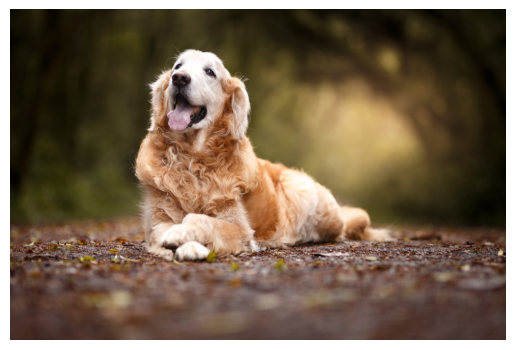

In [14]:
# Display the sample image
plt.imshow(img)
plt.axis('off')
plt.show()

In [15]:
#Define a function to preprocess the image
def preprocess_image(image):
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return preprocess(image).unsqueeze(0)  # Add batch dimension


In [16]:
# Preprocess the sample image
input_image = preprocess_image(img)

In [17]:
# Run the image through AlexNet and get predictions
with torch.no_grad():
    output = model(input_image)

# Load ImageNet class labels
LABELS_URL = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
labels = requests.get(LABELS_URL).json()

In [18]:
# Get the top 5 predictions
_, indices = torch.topk(output, 5)
predictions = [(labels[idx], output[0, idx].item()) for idx in indices[0]]

# Display the predictions
print("Top 5 Predictions:")
for label, score in predictions:
    print(f"{label}: {score:.4f}")



Top 5 Predictions:
Golden Retriever: 17.3823
Cocker Spaniels: 15.8334
English Setter: 14.3717
Clumber Spaniel: 14.3201
Sussex Spaniel: 13.7514


In [19]:
# Visualizing AlexNet Architecture
from torchsummary import summary
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 55, 55]          23,296
              ReLU-2           [-1, 64, 55, 55]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 256, 6, 6]               0
AdaptiveAvgPool2d-14            [-1, 25